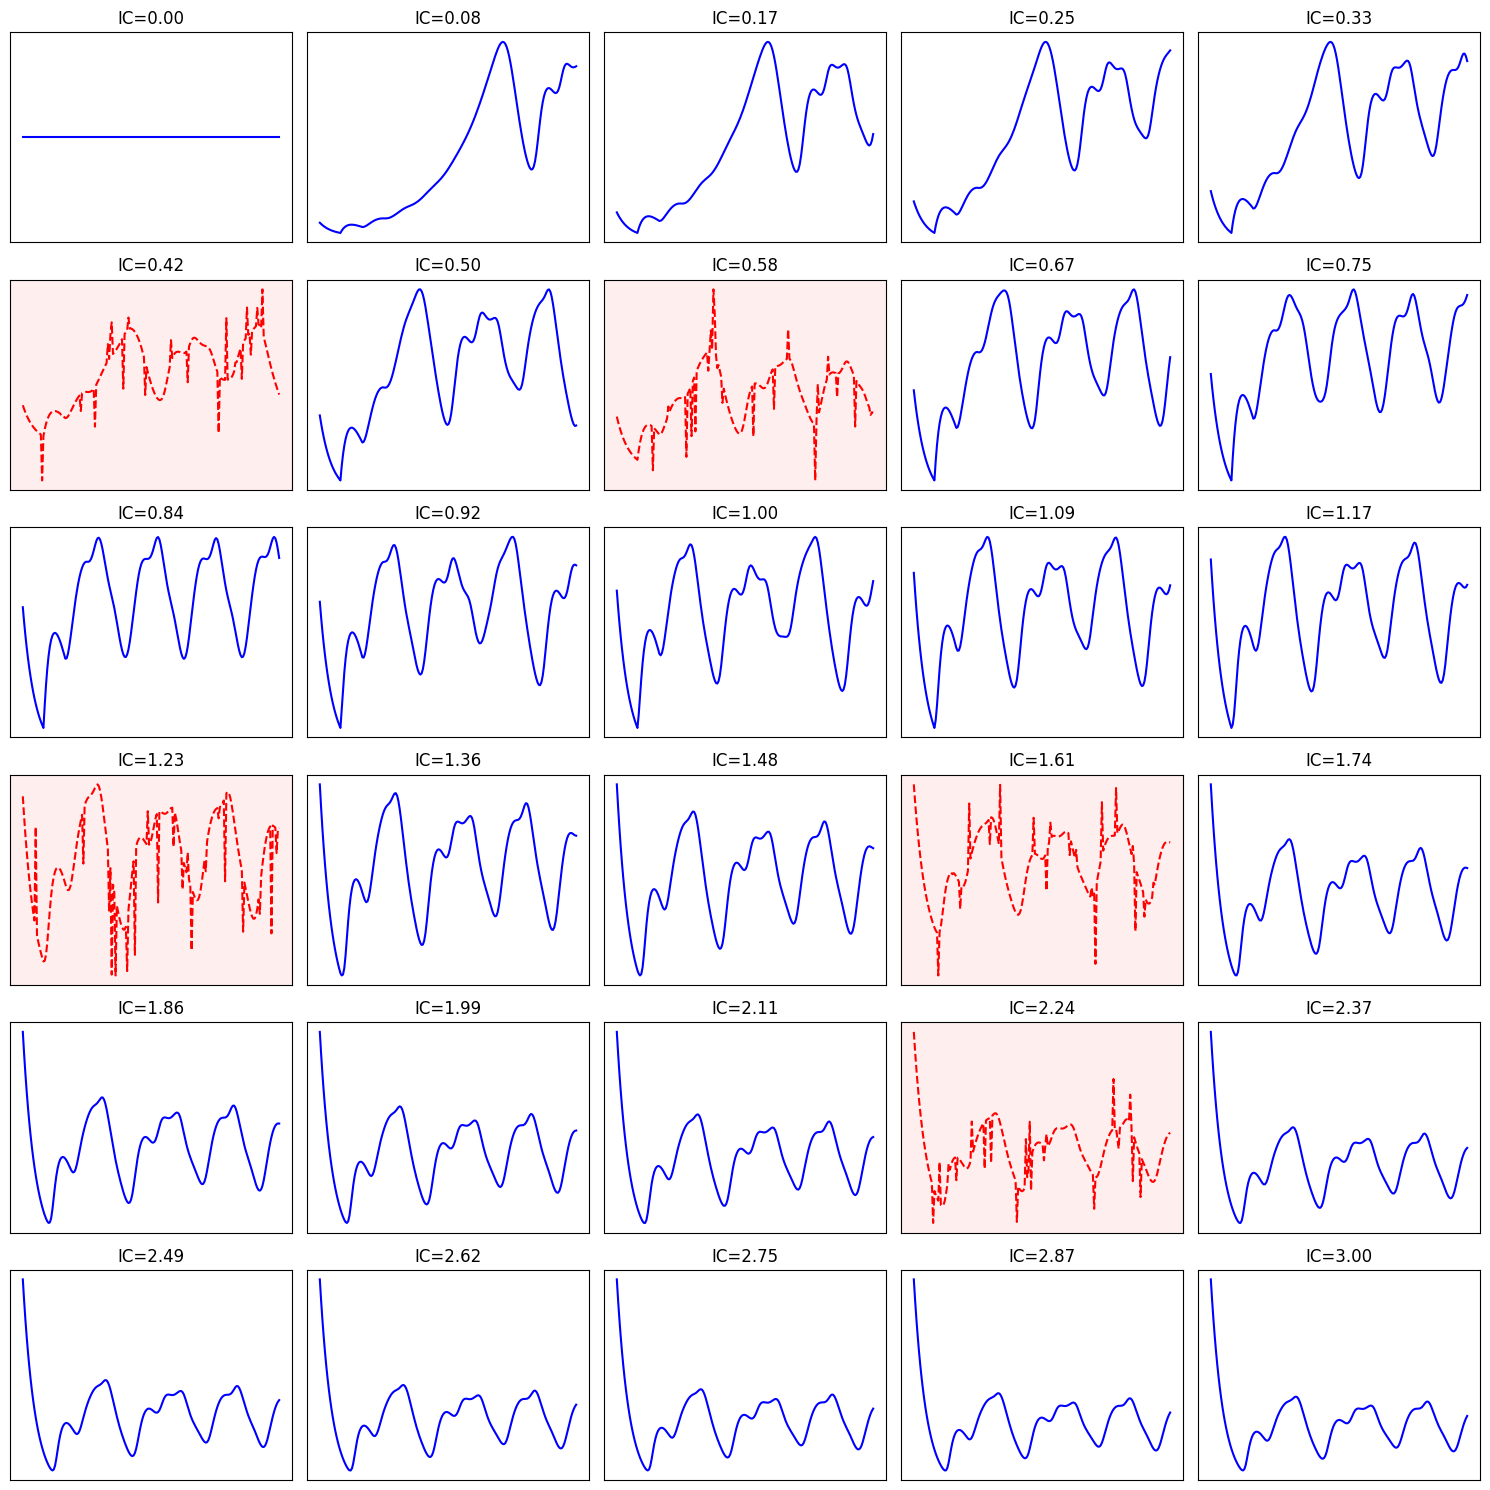

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:616: UserWarning: Using a target size (torch.Size([200])) that is different to the input size (torch.Size([1, 200])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Epoch 0: Train Loss = 0.4324, Val Loss = 0.1394
Epoch 10: Train Loss = 0.0874, Val Loss = 0.0659
Epoch 20: Train Loss = 0.0891, Val Loss = 0.0494
Epoch 30: Train Loss = 0.0842, Val Loss = 0.0463
Epoch 40: Train Loss = 0.0813, Val Loss = 0.0431
Epoch 50: Train Loss = 0.0810, Val Loss = 0.0560
Epoch 60: Train Loss = 0.0790, Val Loss = 0.0426
Epoch 70: Train Loss = 0.0735, Val Loss = 0.0466
Epoch 80: Train Loss = 0.0747, Val Loss = 0.0421
Epoch 90: Train Loss = 0.0684, Val Loss = 0.0403
Epoch 100: Train Loss = 0.0676, Val Loss = 0.0438
Epoch 110: Train Loss = 0.0636, Val Loss = 0.0417
Epoch 120: Train Loss = 0.0663, Val Loss = 0.0399
Epoch 130: Train Loss = 0.0623, Val Loss = 0.0392
Epoch 140: Train Loss = 0.0579, Val Loss = 0.0465
Epoch 150: Train Loss = 0.0496, Val Loss = 0.0347
Epoch 160: Train Loss = 0.0448, Val Loss = 0.0360
Epoch 170: Train Loss = 0.0448, Val Loss = 0.0391
Epoch 180: Train Loss = 0.0416, Val Loss = 0.0391
Epoch 190: Train Loss = 0.0507, Val Loss = 0.0444


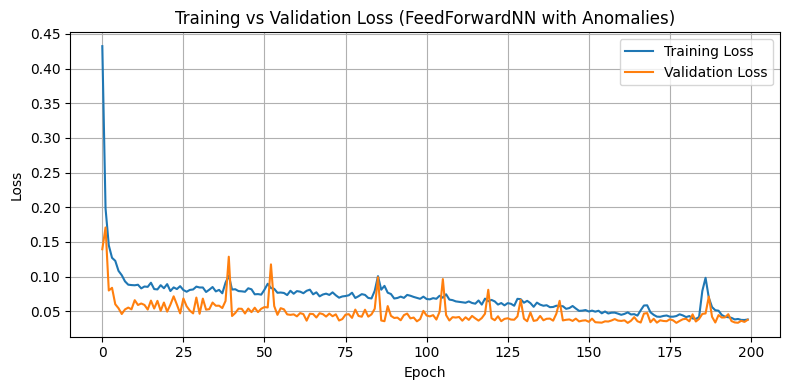


Test RMSE (IC=1.2): 0.1622
Test R² (IC=1.2):   0.6289
F-statistic: 166.9561
P-value:     1.1102e-16
Total Runtime: 8.13 seconds


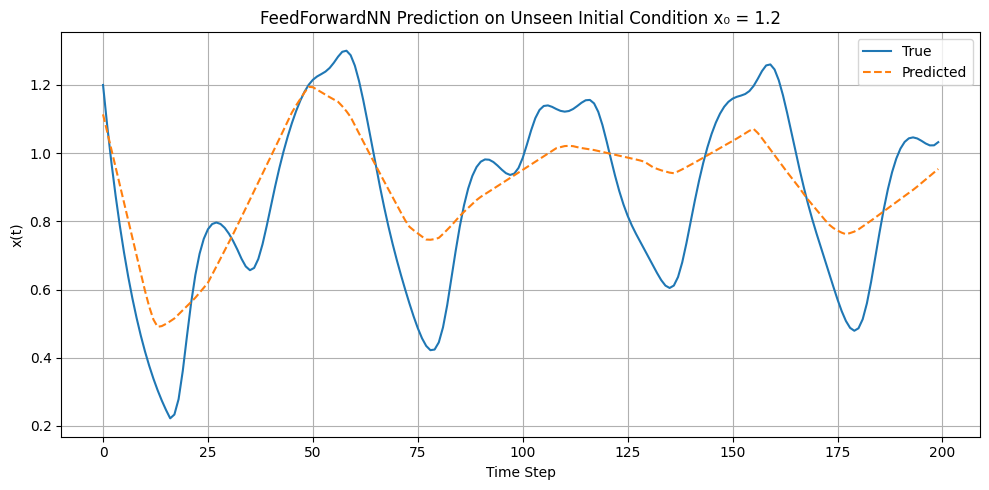

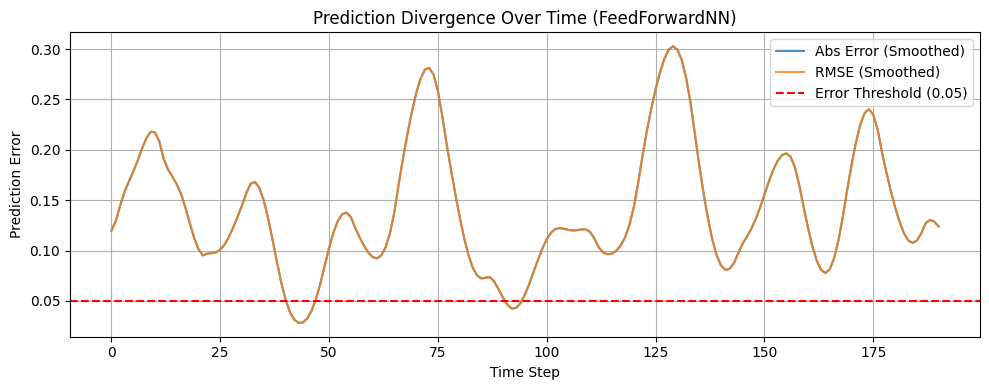

Prediction horizon at threshold 0.05: 0 steps
Total runtime: 8.52 seconds


In [22]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import f
import math
import time
import random

# --- 1. Fix Python, NumPy, and random seeds ---
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

# --- Mackey-Glass Generator ---
def mackey_glass(t_max, tau=17, delta_t=1, beta=0.2, gamma=0.1, n=10, x0=1.2):
    t_len = int(t_max / delta_t)
    x = np.zeros(t_len)
    x[0] = x0
    for t in range(1, t_len):
        if t - tau >= 0:
            x[t] = x[t - 1] + delta_t * (
                beta * x[t - tau] / (1 + x[t - tau] ** n) - gamma * x[t - 1]
            )
        else:
            x[t] = x[t - 1] - delta_t * gamma * x[t - 1]
    return x
# --- Function to insert anomalies ---
def insert_anomalies(x, anomaly_rate=0.05, anomaly_scale=0.5):
    """
    Insert anomalies into a time series.
    anomaly_rate: fraction of points that are anomalous
    anomaly_scale: magnitude of anomalies
    """
    x_anom = x.copy()
    n_points = len(x)
    n_anomalies = int(n_points * anomaly_rate)

    anomaly_indices = np.random.choice(n_points, size=n_anomalies, replace=False)
    for idx in anomaly_indices:
        x_anom[idx] += np.random.uniform(-anomaly_scale, anomaly_scale)
    return x_anom

# --- Parameters ---
t_max = 200
delta_t = 1
train_ics_left = np.linspace(0, 1.17, 15)
train_ics_right = np.linspace(1.23, 3, 15)
train_ics = np.concatenate((train_ics_left, train_ics_right))
test_ic = 1.2
timesteps = np.arange(0, t_max, delta_t)

# --- Generate training data (with anomalies on 5 sequences) ---
X_list, y_list = [], []
rng = np.random.default_rng()  # independent generator (no fixed seed)
anomalous_indices = [15, 5, 23, 7, 18]

for i, ic in enumerate(train_ics):
    x = mackey_glass(t_max=t_max, x0=ic)
    if i in anomalous_indices:
        x = insert_anomalies(x, anomaly_rate=0.1, anomaly_scale=0.7)  # insert anomalies
    norm_t = timesteps / t_max
    features = np.stack([np.full_like(norm_t, ic), norm_t], axis=1)
    X_list.append(features)
    y_list.append(x)

X = np.vstack(X_list)
y = np.concatenate(y_list)

import math

# Number of rows and columns for subplot grid
n_traj = len(y_list)
n_cols = 5  # you can change this
n_rows = math.ceil(n_traj / n_cols)

plt.figure(figsize=(n_cols*3, n_rows*2.5))

for i, x in enumerate(y_list):
    plt.subplot(n_rows, n_cols, i+1)
    if i in anomalous_indices:
        plt.plot(x, 'r--', label=f"IC={train_ics[i]:.2f} (Anomalous)")
    else:
        plt.plot(x, 'b-', label=f"IC={train_ics[i]:.2f}")
    plt.title(f"IC={train_ics[i]:.2f}")
    plt.xticks([])
    plt.yticks([])
    if i in anomalous_indices:
        plt.gca().set_facecolor("#ffeeee")  # light red background for anomalies

plt.tight_layout()
plt.show()



# --- Generate test data ---
x_test = mackey_glass(t_max=200, x0=test_ic)
norm_t_test = timesteps / t_max
X_test = np.stack([np.full_like(norm_t_test, test_ic), norm_t_test], axis=1)
y_test = x_test

# --- Normalize features ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_test_scaled = scaler.transform(X_test)

# --- Prepare torch datasets ---
X_tensor = torch.tensor(X_scaled, dtype=torch.float32).reshape(len(train_ics), t_max, 2)
y_tensor = torch.tensor(y, dtype=torch.float32).reshape(len(train_ics), t_max)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32).unsqueeze(0)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(0)

# Split into train and validation (36 train, 4 val)
val_split = 1
train_len = len(train_ics) - val_split
train_dataset, val_dataset = random_split(TensorDataset(X_tensor, y_tensor), [train_len, val_split])
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=4)


# --- Feed Forward Network ---
class FeedForwardNN(nn.Module):
    def __init__(self, input_size=2, hidden_size=128):
        super(FeedForwardNN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, 1)
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)

model = FeedForwardNN()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# --- Train ---
train_losses, val_losses = [], []
start_time = time.time()
epochs = 200

for epoch in range(epochs):
    model.train()
    total_train_loss = 0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb.squeeze())
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()

    model.eval()
    total_val_loss = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            pred = model(xb)
            val_loss = criterion(pred, yb.squeeze())
            total_val_loss += val_loss.item()

    avg_train_loss = total_train_loss / len(train_loader)
    avg_val_loss = total_val_loss / len(val_loader)
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

    if epoch % 10 == 0:
        print(f"Epoch {epoch}: Train Loss = {avg_train_loss:.4f}, Val Loss = {avg_val_loss:.4f}")

end_time = time.time()

# --- Plot Training vs Validation Loss ---
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss (FeedForwardNN with Anomalies)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Test ---
model.eval()
with torch.no_grad():
    pred_test = model(X_test_tensor).squeeze(0).numpy()

rmse = np.sqrt(mean_squared_error(y_test, pred_test))
r2 = r2_score(y_test, pred_test)
print(f"\nTest RMSE (IC={test_ic}): {rmse:.4f}")
print(f"Test R² (IC={test_ic}):   {r2:.4f}")

# --- F-statistic and p-value ---
n = len(y_test)
k = X_test.shape[1]
F_stat = (r2 / k) / ((1 - r2) / (n - k - 1))
p_value = 1 - f_dist.cdf(F_stat, k, n - k - 1)
print(f"F-statistic: {F_stat:.4f}")
print(f"P-value:     {p_value:.4e}")
print(f"Total Runtime: {end_time - start_time:.2f} seconds")

# --- Plot Test Prediction ---
plt.figure(figsize=(10, 5))
plt.plot(y_test, label='True')
plt.plot(pred_test, label='Predicted', linestyle='--')
plt.title(f"FeedForwardNN Prediction on Unseen Initial Condition x₀ = {test_ic}")
plt.xlabel("Time Step")
plt.ylabel("x(t)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Prediction Divergence / Horizon ---
errors = np.abs(pred_test - y_test)
rmse_window = np.sqrt((pred_test - y_test)**2)

def moving_avg(x, w=10):
    return np.convolve(x, np.ones(w)/w, mode='valid')

window_size = 10
smoothed_error = moving_avg(errors, w=window_size)
smoothed_rmse = moving_avg(rmse_window, w=window_size)

plt.figure(figsize=(10, 4))
plt.plot(smoothed_error, label="Abs Error (Smoothed)", alpha=0.8)
plt.plot(smoothed_rmse, label="RMSE (Smoothed)", alpha=0.8)
plt.axhline(y=0.05, color='r', linestyle='--', label='Error Threshold (0.05)')
plt.title("Prediction Divergence Over Time (FeedForwardNN)")
plt.xlabel("Time Step")
plt.ylabel("Prediction Error")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

threshold = 0.05
divergence_time = np.argmax(smoothed_error > threshold)
print(f"Prediction horizon at threshold {threshold}: {divergence_time} steps")
print(f"Total runtime: {time.time() - start_time:.2f} seconds")


Pearson correlation: 0.8423
Spearman correlation: 0.8525
Spectral cosine similarity: 0.8745


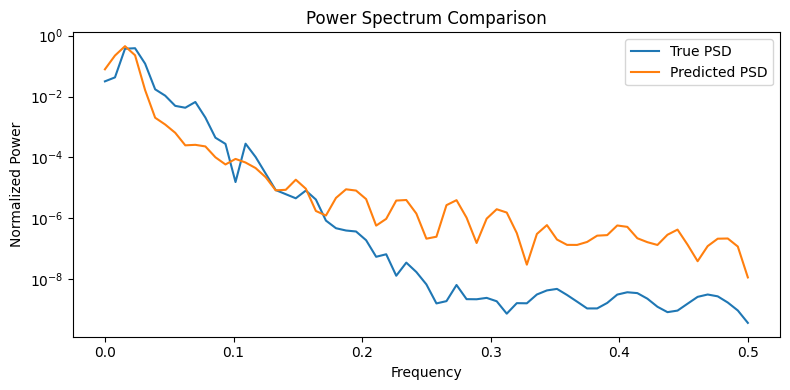

In [23]:
from scipy.stats import pearsonr, spearmanr

def correlation_metrics(y_true, y_pred):
    pearson_corr, _ = pearsonr(y_true, y_pred)
    spearman_corr, _ = spearmanr(y_true, y_pred)
    return pearson_corr, spearman_corr

pearson_corr, spearman_corr = correlation_metrics(y_test, pred_test)
print(f"Pearson correlation: {pearson_corr:.4f}")
print(f"Spearman correlation: {spearman_corr:.4f}")

from scipy.signal import welch
from numpy.linalg import norm

def spectral_similarity(y_true, y_pred, fs=1.0):
    # Welch’s method for power spectral density (PSD)
    f_true, Pxx_true = welch(y_true, fs=fs, nperseg=128)
    f_pred, Pxx_pred = welch(y_pred, fs=fs, nperseg=128)

    # Normalize
    Pxx_true /= np.sum(Pxx_true)
    Pxx_pred /= np.sum(Pxx_pred)

    # Cosine similarity
    cosine_sim = np.dot(Pxx_true, Pxx_pred) / (norm(Pxx_true) * norm(Pxx_pred))
    return cosine_sim, f_true, Pxx_true, Pxx_pred

cos_sim, f, spec_true, spec_pred = spectral_similarity(y_test, pred_test)
print(f"Spectral cosine similarity: {cos_sim:.4f}")

# Plot spectra
plt.figure(figsize=(8,4))
plt.semilogy(f, spec_true, label="True PSD")
plt.semilogy(f, spec_pred, label="Predicted PSD")
plt.title("Power Spectrum Comparison")
plt.xlabel("Frequency")
plt.ylabel("Normalized Power")
plt.legend()
plt.tight_layout()
plt.show()

RMSE: 0.1622
R^2: 0.6289
Pearson correlation: 0.8423
Spearman correlation: 0.8525
Spectral cosine similarity: 0.8745
